# ChoiceIQ Notebook 2 — Model Training, Comparison & Evaluation

ChoiceIQ compares two content-based nearest-neighbour models: cosine distance and Euclidean distance.

In [1]:
from pathlib import Path
import pandas as pd
import joblib, json, subprocess, sys
BASE=Path('..').resolve()
DATA=BASE/'Data'/'processed'
MODELS=BASE/'models'
careers=pd.read_csv(DATA/'choiceiq_careers.csv')
careers.shape

(30, 22)

## 1. Train the two models
`train_models.py` fits both k-NN models and saves their artifacts.

In [2]:
result=subprocess.run([sys.executable, str(BASE/'train_models.py')], cwd=BASE, capture_output=True, text=True)
print(result.stdout)
if result.stderr: print(result.stderr)

    model  precision_at_3  recall_at_3  f1_at_3      mrr  benchmark_profiles
   Cosine        0.600000     0.600000 0.600000 0.820000                  10
Euclidean        0.466667     0.466667 0.466667 0.808333                  10



## 2. Evaluation metrics
Because this prototype has no historical user-rating dataset, evaluation uses 10 expert-defined benchmark profiles with three relevant careers per profile. This is a demonstration benchmark, not a population-level accuracy estimate.

In [3]:
evaluation=pd.read_csv(DATA/'model_evaluation.csv')
evaluation

,model,precision_at_3,recall_at_3,f1_at_3,mrr,benchmark_profiles
0,Cosine,0.600000,0.600000,0.600000,0.820000,10
1,Euclidean,0.466667,0.466667,0.466667,0.808333,10


In [4]:
details=pd.read_csv(DATA/'model_evaluation_details.csv')
details[['model','profile','top_3','hits','precision_at_3','recall_at_3','f1_at_3','reciprocal_rank']].head(20)

,model,profile,top_3,hits,precision_at_3,recall_at_3,f1_at_3,reciprocal_rank
0,Cosine,Data & research,Data Analyst | Data Scientist | Data Engineer,3,1.000000,1.000000,1.000000,1.000000
1,Cosine,Software builder,Software Tester | Web Developer | Software Dev...,2,0.666667,0.666667,0.666667,0.500000
2,Cosine,Cyber investigator,Ethical Hacker | Ict Security Technician | Dig...,2,0.666667,0.666667,0.666667,1.000000
3,Cosine,Network infrastructure,Ict Network Administrator | Ict System Adminis...,2,0.666667,0.666667,0.666667,1.000000
4,Cosine,Cloud platform,Ict Network Administrator | Ict Technician | I...,0,0.000000,0.000000,0.000000,0.200000
5,Cosine,Security operations,Ict Security Administrator | Ict Security Tech...,2,0.666667,0.666667,0.666667,1.000000
6,Cosine,Systems analysis,Ict System Analyst | Ict Network Administrator...,2,0.666667,0.666667,0.666667,1.000000
7,Cosine,UX interface,User Interface Designer | Ict System Architect...,1,0.333333,0.333333,0.333333,1.000000
8,Cosine,Database,Database Developer | Database Administrator | ...,3,1.000000,1.000000,1.000000,1.000000
9,Cosine,IT support,Ict System Analyst | Ict Help Desk Agent | Ict...,1,0.333333,0.333333,0.333333,0.500000


## 3. Model selection
The deployed model is cosine content-based k-NN because it performs better on Precision@3/F1@3 in the prototype benchmark and is easy to explain.

In [5]:
meta=json.loads((MODELS/'model_metadata.json').read_text())
meta

{'selected_model': 'Cosine content-based k-NN',
 'selection_reason': 'Higher Precision@3 and F1@3 on the expert-defined benchmark profiles, while remaining easy to explain.',
 'features': ['data_analytics',
  'programming',
  'mathematics',
  'cybersecurity',
  'networking',
  'problem_solving',
  'creativity_design',
  'systems_cloud',
  'communication_business'],
 'career_count': 30,
 'evaluation_note': 'Evaluation uses 10 expert-defined prototype profiles because no historical user-rating dataset is available. Metrics are demonstration metrics, not population-level accuracy claims.',
 'selected_metrics': {'precision_at_3': 0.5999999999999999,
  'recall_at_3': 0.5999999999999999,
  'f1_at_3': 0.5999999999999999,
  'mrr': 0.82,
  'benchmark_profiles': 10}}

## 4. Saved model files

In [6]:
sorted([p.name for p in MODELS.iterdir()])

['career_feature_bundle.joblib',
 'cosine_knn.joblib',
 'euclidean_knn.joblib',
 'model_metadata.json']

## 5. Model evaluation visuals

These cells reproduce the figures used in the Model Selection and Evaluation Report and presentation.

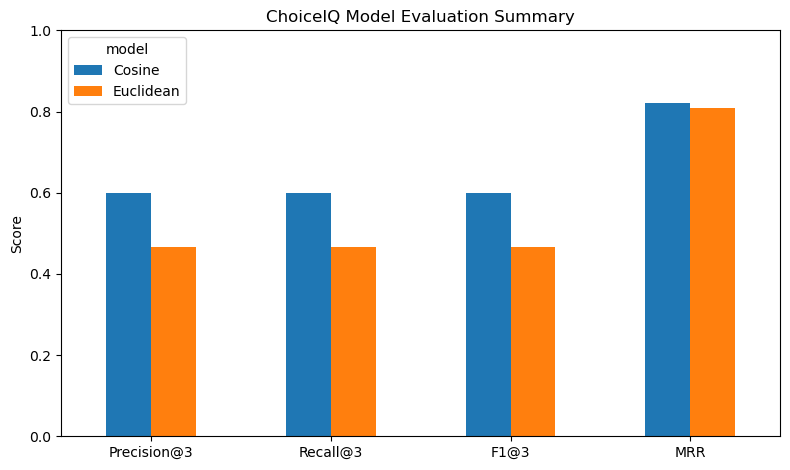

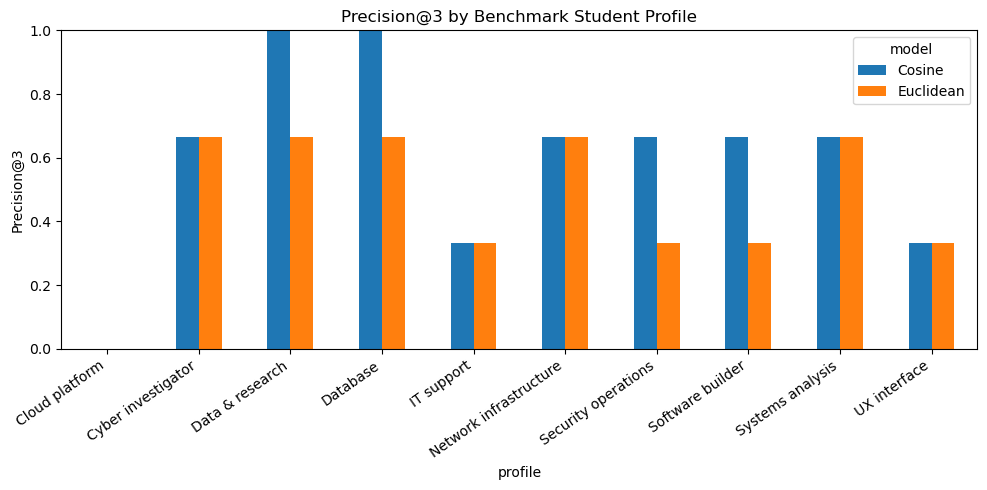

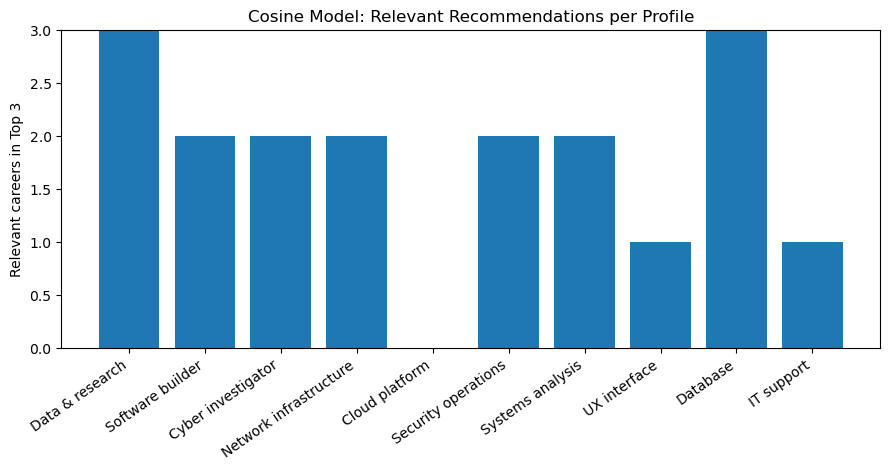

In [7]:
import matplotlib.pyplot as plt
import numpy as np
FIG=BASE/'assets'/'figures'; FIG.mkdir(parents=True,exist_ok=True)
evaluation=pd.read_csv(DATA/'model_evaluation.csv'); details=pd.read_csv(DATA/'model_evaluation_details.csv')
metrics=['precision_at_3','recall_at_3','f1_at_3','mrr']; plot_df=evaluation.set_index('model')[metrics].T; ax=plot_df.plot(kind='bar',figsize=(8,4.8)); ax.set_ylim(0,1); ax.set_ylabel('Score'); ax.set_title('ChoiceIQ Model Evaluation Summary'); ax.set_xticklabels(['Precision@3','Recall@3','F1@3','MRR'],rotation=0); plt.tight_layout(); plt.savefig(FIG/'01_model_summary.png',dpi=160); plt.show()
pivot=details.pivot(index='profile',columns='model',values='precision_at_3'); pivot.plot(kind='bar',figsize=(10,5)); plt.ylim(0,1); plt.ylabel('Precision@3'); plt.title('Precision@3 by Benchmark Student Profile'); plt.xticks(rotation=35,ha='right'); plt.tight_layout(); plt.savefig(FIG/'02_profile_precision.png',dpi=160); plt.show()
cosine=details[details['model'].eq('Cosine')].copy(); plt.figure(figsize=(9,4.8)); plt.bar(cosine['profile'],cosine['hits']); plt.ylabel('Relevant careers in Top 3'); plt.title('Cosine Model: Relevant Recommendations per Profile'); plt.ylim(0,3); plt.xticks(rotation=35,ha='right'); plt.tight_layout(); plt.savefig(FIG/'03_cosine_hits.png',dpi=160); plt.show()

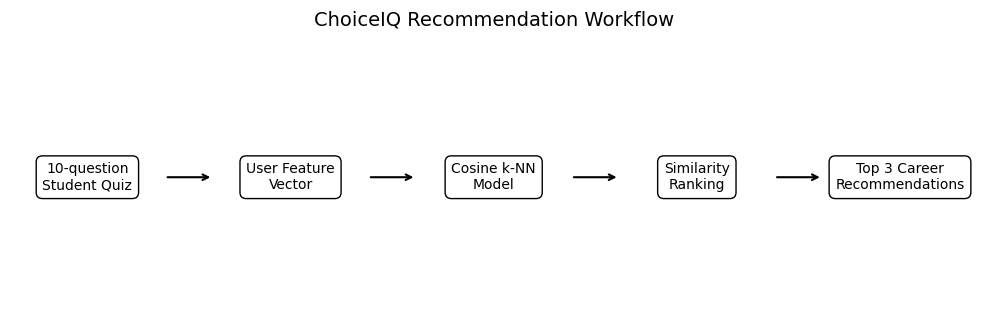

In [8]:
fig,ax=plt.subplots(figsize=(10,3.3)); ax.axis('off'); steps=['10-question\nStudent Quiz','User Feature\nVector','Cosine k-NN\nModel','Similarity\nRanking','Top 3 Career\nRecommendations']; x=np.linspace(0.08,0.92,len(steps))
for i,(xi,step) in enumerate(zip(x,steps)):
    ax.text(xi,0.5,step,ha='center',va='center',bbox=dict(boxstyle='round,pad=0.45',fc='white',ec='black'))
    if i<len(steps)-1: ax.annotate('',xy=(x[i+1]-0.08,0.5),xytext=(xi+0.08,0.5),arrowprops=dict(arrowstyle='->',lw=1.5))
ax.set_title('ChoiceIQ Recommendation Workflow',pad=14,fontsize=14); plt.tight_layout(); plt.savefig(FIG/'04_recommendation_workflow.png',dpi=160,bbox_inches='tight'); plt.show()